# Credit Card Fraud Detection using XGBoost & Streamlit

## 1. Import Libraries


In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)
from xgboost import XGBClassifier

np.random.seed(42)
sns.set_theme(style="whitegrid")
print("All required libraries imported successfully!")


All required libraries imported successfully!


## 2. Load Dataset


In [2]:
df = pd.read_csv("../data/creditcard.csv")

print("--- First 5 Rows ---")
print(df.head())


--- First 5 Rows ---
   Time        V1        V2        V3  ...       V27       V28  Amount  Class
0   0.0 -1.359807 -0.072781  2.536347  ...  0.133558 -0.021053  149.62      0
1   0.0  1.191857  0.266151  0.166480  ... -0.008983  0.014724    2.69      0
2   1.0 -1.358354 -1.340163  1.773209  ... -0.055353 -0.059752  378.66      0
3   1.0 -0.966272 -0.185226  1.792993  ...  0.062723  0.061458  123.50      0
4   2.0 -1.158233  0.877737  1.548718  ...  0.219422  0.215153   69.99      0

[5 rows x 31 columns]


In [3]:
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("--- Dataset Information ---")
df.info()


Dataset Shape: 284807 rows, 31 columns

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non

In [4]:
print("--- Summary Statistics ---")
print(df.describe())


--- Summary Statistics ---
                Time            V1  ...         Amount          Class
count  284807.000000  2.848070e+05  ...  284807.000000  284807.000000
mean    94813.859575  1.175161e-15  ...      88.349619       0.001727
std     47488.145955  1.958696e+00  ...     250.120109       0.041527
min         0.000000 -5.640751e+01  ...       0.000000       0.000000
25%     54201.500000 -9.203734e-01  ...       5.600000       0.000000
50%     84692.000000  1.810880e-02  ...      22.000000       0.000000
75%    139320.500000  1.315642e+00  ...      77.165000       0.000000
max    172792.000000  2.454930e+00  ...   25691.160000       1.000000

[8 rows x 31 columns]


In [5]:
print("--- Missing Values Check ---")
print(f"Total missing values: {df.isnull().sum().sum()}")

print("\n--- Target Class Distribution (Class) ---")
class_counts = df['Class'].value_counts()
class_percentage = df['Class'].value_counts(normalize=True) * 100

for label, count in class_counts.items():
    name = "Fraudulent (1)" if label == 1 else "Legitimate (0)"
    pct = class_percentage[label]
    print(f"  {name}: {count:,} transactions ({pct:.4f}%)")


--- Missing Values Check ---
Total missing values: 0

--- Target Class Distribution (Class) ---
  Legitimate (0): 284,315 transactions (99.8273%)
  Fraudulent (1): 492 transactions (0.1727%)


## 3. Basic Data Preprocessing


In [6]:
X = df.drop(columns=['Time', 'Class'])
y = df['Class']

print(f"Feature matrix (X) shape: {X.shape}")
print(f"Target vector (y) shape:  {y.shape}")
print(f"Feature columns ({len(X.columns)}):", list(X.columns)[:6], "...", list(X.columns)[-3:])

preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', RobustScaler(), ['Amount'])
    ],
    remainder='passthrough'
)
print("\nColumnTransformer configured: RobustScaler for 'Amount', passthrough for V1-V28.")


Feature matrix (X) shape: (284807, 29)
Target vector (y) shape:  (284807,)
Feature columns (29): ['V1', 'V2', 'V3', 'V4', 'V5', 'V6'] ... ['V27', 'V28', 'Amount']

ColumnTransformer configured: RobustScaler for 'Amount', passthrough for V1-V28.


## 4. Train / Test Split


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]:,} samples (Frauds: {y_train.sum()})")
print(f"Testing set:  {X_test.shape[0]:,} samples (Frauds: {y_test.sum()})")

print("\nClass balance in Train:")
print(y_train.value_counts(normalize=True).round(6).to_dict())

print("\nClass balance in Test:")
print(y_test.value_counts(normalize=True).round(6).to_dict())


Training set: 227,845 samples (Frauds: 394)
Testing set:  56,962 samples (Frauds: 98)

Class balance in Train:
{0: 0.998271, 1: 0.001729}

Class balance in Test:
{0: 0.99828, 1: 0.00172}


## 5. Train XGBoost Model


In [8]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb_model)
])

print("Training XGBoost pipeline on 227,845 samples...")
model.fit(X_train, y_train)
print("XGBoost pipeline successfully trained!")


Training XGBoost pipeline on 227,845 samples...
XGBoost pipeline successfully trained!


## 6. Model Evaluation


In [9]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("=" * 45)
print("         MODEL PERFORMANCE METRICS           ")
print("=" * 45)
print(f"Accuracy  : {acc:.6f} ({acc * 100:.4f}%)")
print(f"Precision : {prec:.4f} ({prec * 100:.2f}%)")
print(f"Recall    : {rec:.4f} ({rec * 100:.2f}%)")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print("=" * 45)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, digits=4, target_names=["Legitimate (0)", "Fraud (1)"]))


         MODEL PERFORMANCE METRICS           
Accuracy  : 0.999473 (99.9473%)
Precision : 0.8953 (89.53%)
Recall    : 0.7857 (78.57%)
F1-Score  : 0.8370
ROC-AUC   : 0.9606

--- Classification Report ---
                precision    recall  f1-score   support

Legitimate (0)     0.9996    0.9998    0.9997     56864
     Fraud (1)     0.8953    0.7857    0.8370        98

      accuracy                         0.9995     56962
     macro avg     0.9475    0.8928    0.9183     56962
  weighted avg     0.9995    0.9995    0.9995     56962



<string>:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


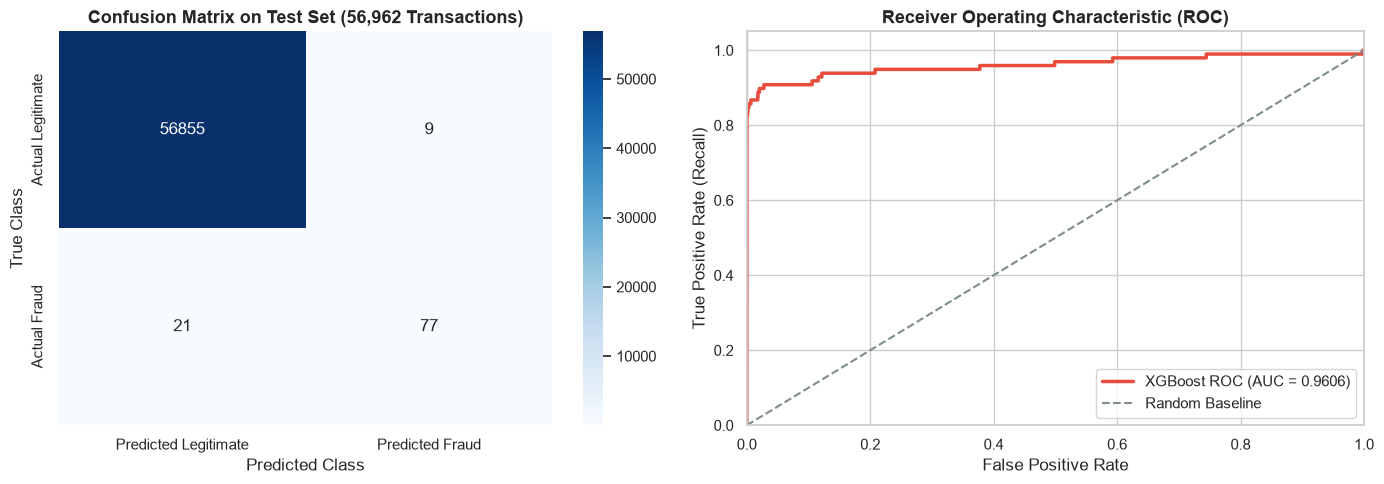

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted Legitimate', 'Predicted Fraud'],
    yticklabels=['Actual Legitimate', 'Actual Fraud'],
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix on Test Set (56,962 Transactions)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Class', fontsize=12)
axes[0].set_xlabel('Predicted Class', fontsize=12)

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2.5, label=f'XGBoost ROC (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='#7f8c8d', lw=1.5, linestyle='--', label='Random Baseline')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate (Recall)', fontsize=12)
axes[1].set_title('Receiver Operating Characteristic (ROC)', fontsize=13, fontweight='bold')
axes[1].legend(loc="lower right", fontsize=11)

plt.tight_layout()
plt.show()


## 7. Save Model Pipeline


In [11]:
os.makedirs("../model", exist_ok=True)
model_path = "../model/fraud_detection_model.joblib"

joblib.dump(model, model_path)
print(f"Model artifact successfully saved to: {model_path}")

loaded_model = joblib.load(model_path)

fraud_idx = y_test[y_test == 1].index[0]
sample_fraud_tx = pd.DataFrame([X_test.loc[fraud_idx]])

pred = loaded_model.predict(sample_fraud_tx)[0]
prob = loaded_model.predict_proba(sample_fraud_tx)[0][1]

print("\n--- Verification on Real Test Fraud Sample ---")
print(f"True Label       : 1 (Fraud)")
print(f"Model Prediction : {'⚠️ Fraudulent (1)' if pred == 1 else '✅ Legitimate (0)'}")
print(f"Fraud Probability: {prob:.4f} ({prob * 100:.2f}%)")
print("\nVerification complete: model artifact is ready for Streamlit deployment!")


Model artifact successfully saved to: ../model/fraud_detection_model.joblib

--- Verification on Real Test Fraud Sample ---
True Label       : 1 (Fraud)
Model Prediction : ⚠️ Fraudulent (1)
Fraud Probability: 0.9913 (99.13%)

Verification complete: model artifact is ready for Streamlit deployment!
